<a href="https://colab.research.google.com/github/aniray2908/ML-foundations-rebuild/blob/main/unsupervised_learning/demos/06_pca_clustering_interaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCA and Clustering Interaction

Goal:
- Show when PCA helps clustering
- Show when PCA hurts clustering
- Visualize variance vs separation tradeoff
- Examine distance concentration behavior

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

In [2]:
# 2 informative dimensions
X_signal, _ = make_blobs(n_samples=500, centers=3, cluster_std=1.0, random_state=42)

# Add 20 noisy dimensions
noise = np.random.normal(0, 5, size=(500, 20))

X_high_dim = np.hstack([X_signal, noise])

In [3]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_before = kmeans.fit_predict(X_high_dim)

print("Silhouette before PCA:", silhouette_score(X_high_dim, labels_before))

Silhouette before PCA: 0.060702374389004575


In [4]:
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_high_dim)

labels_after = kmeans.fit_predict(X_reduced)

print("Silhouette after PCA:", silhouette_score(X_reduced, labels_after))

Silhouette after PCA: 0.45383841054427293


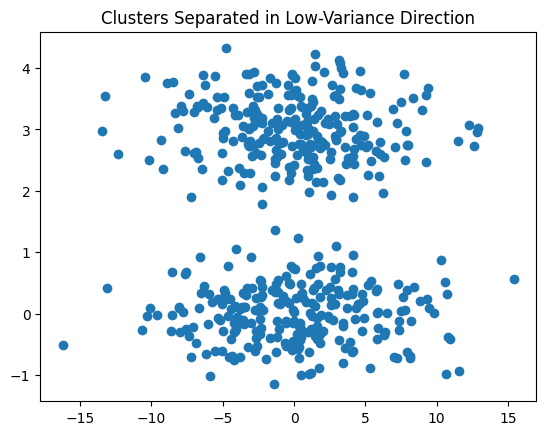

In [5]:
np.random.seed(42)

cluster1 = np.random.normal(loc=[0,0], scale=[5,0.5], size=(250,2))
cluster2 = np.random.normal(loc=[0,3], scale=[5,0.5], size=(250,2))

X_bad = np.vstack([cluster1, cluster2])

plt.scatter(X_bad[:,0], X_bad[:,1])
plt.title("Clusters Separated in Low-Variance Direction")
plt.show()

In [6]:
kmeans2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_bad_before = kmeans2.fit_predict(X_bad)

print("Silhouette before PCA:", silhouette_score(X_bad, labels_bad_before))

Silhouette before PCA: 0.4565469071867176


In [7]:
pca_bad = PCA(n_components=1)
X_bad_reduced = pca_bad.fit_transform(X_bad)

labels_bad_after = kmeans2.fit_predict(X_bad_reduced)

print("Silhouette after PCA:", silhouette_score(X_bad_reduced, labels_bad_after))

Silhouette after PCA: 0.5417574812890815


In [8]:
def distance_spread(X):
    dists = pairwise_distances(X)
    return np.max(dists) - np.min(dists)

print("Distance spread before PCA:", distance_spread(X_high_dim))
print("Distance spread after PCA:", distance_spread(X_reduced))

Distance spread before PCA: 55.50591380842445
Distance spread after PCA: 36.29771367730852


Observations:

1. PCA improves clustering when it removes noisy dimensions.
2. PCA can destroy clustering when separation lies in low-variance directions.
3. PCA optimizes total variance, not separation.
4. Clustering quality depends on alignment between variance and signal.

PCA is a variance filter, not a clustering objective.